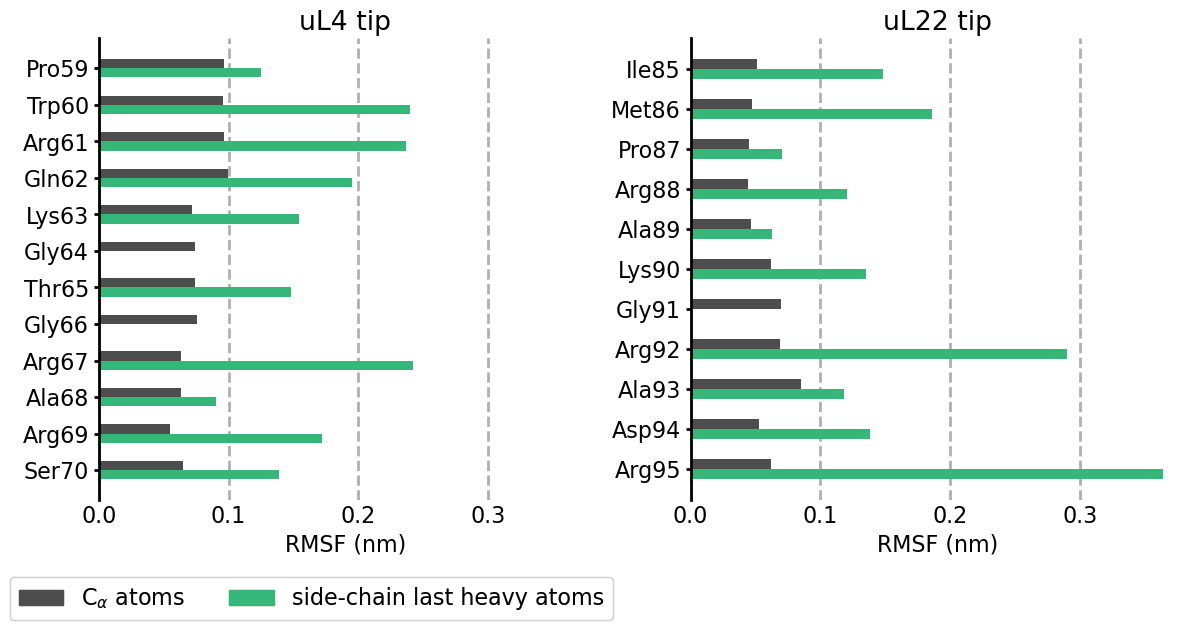

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


plt.rc("axes", axisbelow=True)
plt.rcParams.update(
    {
        "font.size": 16,
    }
)

RESULTS = "../output_files/rmsf/"
LABELS = [
    [
        "Pro59",
        "Trp60",
        "Arg61",
        "Gln62",
        "Lys63",
        "Gly64",
        "Thr65",
        "Gly66",
        "Arg67",
        "Ala68",
        "Arg69",
        "Ser70",
    ],
    [
        "Ile85",
        "Met86",
        "Pro87",
        "Arg88",
        "Ala89",
        "Lys90",
        "Gly91",
        "Arg92",
        "Ala93",
        "Asp94",
        "Arg95",
    ],
]
COLORS = {
    "CA": "#4d4d4d",
    "last": "#35b779",
}

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
for i, protein in enumerate(["uL4", "uL22"]):
    for selection in ["CA", "last"]:
        data = np.loadtxt(f"{RESULTS}/experiment.{protein}.{selection}.dat")
        if selection == "CA":
            y = data[0] + 0.125
        else:
            y = data[0] - 0.125
        axs[i].barh(
            y,
            data[1][::-1] / 10,
            height=0.25,
            color=COLORS[selection],
        )
        for spine in axs[i].spines.values():
            spine.set_visible(False)
        axs[i].spines["left"].set_visible(True)
        axs[i].spines["left"].set_linewidth(2)
        axs[i].set_yticks(data[0][::-1], LABELS[i])
        axs[i].tick_params(width=2)
        axs[i].tick_params(axis='x', length=0)
        axs[i].set_title(f"{protein} tip")
        axs[i].set_xlabel("RMSF (nm)")
        axs[i].set_xlim((0, 0.38))
        axs[i].grid(axis="x", linestyle="--", linewidth=2)
    fig.legend(
        handles=[
            mpatches.Patch(color="#4d4d4d", label=r"C$_{\alpha}$ atoms"),
            mpatches.Patch(color="#35b779", label="side-chain last heavy atoms")
        ],
        ncol=2,
        bbox_to_anchor=(0.5, 0)
    )